In [1]:
import pandas as pd

file_path = r"C:\Users\ATHARVA\Downloads\my codes\python\machine_learning\project_web\Data_Phising\CEAS_08.csv"

CEAS_df= pd.read_csv(file_path)

print(CEAS_df.head())

                                              sender  \
0                   Young Esposito <Young@iworld.de>   
1                       Mok <ipline's1983@icable.ph>   
2  Daily Top 10 <Karmandeep-opengevl@universalnet...   
3                 Michael Parker <ivqrnai@pobox.com>   
4  Gretchen Suggs <externalsep1@loanofficertool.com>   

                                         receiver  \
0                     user4@gvc.ceas-challenge.cc   
1                   user2.2@gvc.ceas-challenge.cc   
2                   user2.9@gvc.ceas-challenge.cc   
3  SpamAssassin Dev <xrh@spamassassin.apache.org>   
4                   user2.2@gvc.ceas-challenge.cc   

                              date  \
0  Tue, 05 Aug 2008 16:31:02 -0700   
1  Tue, 05 Aug 2008 18:31:03 -0500   
2  Tue, 05 Aug 2008 20:28:00 -1200   
3  Tue, 05 Aug 2008 17:31:20 -0600   
4  Tue, 05 Aug 2008 19:31:21 -0400   

                                             subject  \
0                          Never agree to be a loser   
1  

In [2]:
CEAS_df['body'] 

0        Buck up, your troubles caused by small dimensi...
1        \nUpgrade your sex and pleasures with these te...
2        >+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...
3        Would anyone object to removing .so from this ...
4        \nWelcomeFastShippingCustomerSupport\nhttp://7...
                               ...                        
39149    \n\nCNN Alerts: My Custom Alert\n\n\n\n\n\n\n ...
39150    \n\nCNN Alerts: My Custom Alert\n\n\n\n\n\n\n ...
39151    Hello there ! \nGreat work on the slide show v...
39152    \nMail from sender , coming from intuit.com\ns...
39153    Dear fellow Pythonistas!\n\nGuido has accepted...
Name: body, Length: 39154, dtype: object

In [3]:
CEAS_df['label'].value_counts()

label
1    21842
0    17312
Name: count, dtype: int64

In [4]:
import re
import pandas as pd

# Regex pattern to extract URLs (robust version)
url_pattern = r'(https?://[^\s]+)'

# Apply extraction conditionally
def extract_urls_from_body(row):
    if row['urls'] > 0 and isinstance(row['body'], str):
        found = re.findall(url_pattern, row['body'])
        if found:
            return " [NEXT] ".join(found)
    return ""

# Create the new column
CEAS_df['URL'] = CEAS_df.apply(extract_urls_from_body, axis=1)


In [5]:

CEAS_df['URL_COUNT'] = CEAS_df['URL'].apply(
    lambda x: 0 if x == "" else x.count(" [NEXT]") + 1
)

In [6]:
CEAS_df['URL']

0                                    http://whitedone.com/
1                                http://www.brightmade.com
2        http://www.cnn.com/video/partners/email/index....
3        http://en.wikipedia.org/wiki/.so_%28domain_nam...
4        http://7iwfna.blu.livefilestore.com/y1pXdX3kwz...
                               ...                        
39149                                                     
39150                                                     
39151                                                     
39152                                                     
39153    http://python.org/dev/peps/pep-0370/ [NEXT] ht...
Name: URL, Length: 39154, dtype: object

In [7]:
DATA_PHISING= CEAS_df[['subject', 'body','URL','label', 'URL_COUNT']]

In [8]:
DATA_PHISING.iloc[3]['URL']


'http://en.wikipedia.org/wiki/.so_%28domain_name%29 [NEXT] http://svn.apache.org/viewvc?rev=619753&view=rev [NEXT] http://svn.apache.org/viewvc/spamassassin/trunk/lib/Mail/SpamAssassin/PerMsgStatus.pm?rev=619753&r1=619752&r2=619753&view=diff [NEXT] http://svn.apache.org/viewvc/spamassassin/trunk/lib/Mail/SpamAssassin/Util/RegistrarBoundaries.pm?rev=619753&r1=619752&r2=619753&view=diff [NEXT] http://www.iana.org/cctld/cctld-whois.htm [NEXT] http://www.iana.org/root-whois/ [NEXT] http://www.iana.org/gtld/gtld.htm [NEXT] http://www.iana.org/arpa-dom/ [NEXT] http://data.iana.org/TLD/tlds-alpha-by-domain.txt [NEXT] http://svn.apache.org/viewvc/spamassassin/trunk/t/uri_text.t?rev=619753&r1=619752&r2=619753&view=diff [NEXT] http://example.foo$ [NEXT] http://example.xxx$ [NEXT] http://example.ac$ [NEXT] http://example.ad$ [NEXT] http://example.ae$ [NEXT] http://example.aero$ [NEXT] http://example.af$ [NEXT] http://example.ag$ [NEXT] http://example.ai$ [NEXT] http://example.al$ [NEXT] http://ex

In [9]:


DATA_PHISING[(DATA_PHISING['label'] == 1) & (DATA_PHISING['URL_COUNT'] == 0)]

,subject,body,URL,label,URL_COUNT
5,From Caroline Aragon,\n\n\n\n\nYo wu urS mo ou go rc ebo eForM rgi ...,,1,0
6,Replica Watches,We have fake Swiss Men's and Ladie's Replica \...,,1,0
25,;) Look porno Gallery!!!,#PjWmcUDemi Moore Full video without cowards.\...,,1,0
29,MBA-Degreees not for sale- get it.,"Bacheelor, MasteerMBA, and Doctoraate diplomas...",,1,0
31,Man's stuff store,\n\n\nLargest selection of medication products...,,1,0
...,...,...,...,...,...
39141,CNN Alerts: My Custom Alert,\n\nCNN Alerts: My Custom Alert\n\n\n\n\n\n\n ...,,1,0
39146,CNN Alerts: My Custom Alert,\n\n\nCNN Alerts: My Custom Alert\n\n\n\n\n\n\...,,1,0
39148,Patients can access Our online health shop is ...,\n\nLab-tested female sensual leverage!\n\nPat...,,1,0
39149,CNN Alerts: My Custom Alert,\n\nCNN Alerts: My Custom Alert\n\n\n\n\n\n\n ...,,1,0


In [10]:
import re

def extract_attachment_names(body):
    # Common MIME pattern for attachments
    pattern = r'filename="([^"]+)"'
    found = re.findall(pattern, body)
    return "\n".join(found) if found else ""

CEAS_df['ATTACHMENTS'] = CEAS_df['body'].apply(
    lambda x: extract_attachment_names(x) if isinstance(x, str) else ""
)

# Count column
CEAS_df['ATTACH_COUNT'] = CEAS_df['ATTACHMENTS'].apply(
    lambda x: len(x.split("\n")) if x else 0
)


In [11]:
import pandas as pd

file_path = r"C:\Users\ATHARVA\Downloads\my codes\python\machine_learning\project_web\Data_Phising\Nazario.csv"

Nazario_df= pd.read_csv(file_path)


In [12]:
Nazario_df['body']

0       This text is part of the internal format of yo...
1       Business with  \t\t\t\t\t\t\t\tcPanel & WHM \t...
2       Your two incoming mails were placed on pending...
3       Password will expire in 3 days. Click Here To ...
4       To ensure delivery to your inbox, please add U...
                              ...                        
1560    PayPal You sent a payment of $699.99 USD to FT...
1561    monkey.org  Hi jose,Pa⁠s⁠sword for⁠ jose@monke...
1562    HELLO,   Please note that, your monthly paymen...
1563    Verify your MetaMask Wallet Our system has sho...
1564    Announcing JotForm Tables: When a spreadsheet ...
Name: body, Length: 1565, dtype: object

In [13]:
Nazario_df['URL'] = Nazario_df.apply(extract_urls_from_body, axis=1)

In [14]:
Nazario_df

,sender,receiver,date,subject,body,urls,label,URL
0,Mail System Internal Data <MAILER-DAEMON@monke...,NaN,28 Sep 2017 09:57:25 -0400,DON'T DELETE THIS MESSAGE -- FOLDER INTERNAL DATA,This text is part of the internal format of yo...,1,1,http://id-redirection.cu.cc/ [NEXT] http://sit...
1,cPanel <service@cpanel.com>,jose@monkey.org,"Fri, 30 Oct 2015 00:00:48 -0500",Verify Your Account,Business with \t\t\t\t\t\t\t\tcPanel & WHM \t...,1,1,
2,Microsoft Outlook <recepcao@unimedceara.com.br>,NaN,"Fri, 30 Oct 2015 06:21:59 -0300 (BRT)",Helpdesk Mailbox Alert!!!,Your two incoming mails were placed on pending...,1,1,
3,Ann Garcia <AnGarcia@mcoe.org>,"""info@maaaaa.org"" <info@maaaaa.org>","Fri, 30 Oct 2015 14:54:33 +0000",IT-Service Help Desk,Password will expire in 3 days. Click Here To ...,0,1,
4,"""USAA"" <usaaacctupdate@sccu4u.com>",Recipients <usaaacctupdate@sccu4u.com>,"Fri, 30 Oct 2015 14:02:33 -0500",Final USAA Reminder - Update Your Account Now,"To ensure delivery to your inbox, please add U...",1,1,
...,...,...,...,...,...,...,...,...
1560,info advantageapartments.com <info@advantageap...,"""jose@monkey.org"" <jose@monkey.org>","Sun, 11 Dec 2022 12:04:50 +0000",Receipt for Your Payment to FTX.,PayPal You sent a payment of $699.99 USD to FT...,0,1,
1561,monkey.org <HELPDESK@monkey.org>,jose@monkey.org,15 Dec 2022 18:33:00 -0500,Rectify Your Password With monkey.org,"monkey.org Hi jose,Pa⁠s⁠sword for⁠ jose@monke...",1,1,
1562,Help Center\n\t<info.help-center.co.za_info.he...,jose@monkey.org,"Tue, 20 Dec 2022 23:00:27 +0000 (UTC)",Netflix : We're having some trouble with your ...,"HELLO, Please note that, your monthly paymen...",1,1,https://netflix.com/update/account/info [NEXT]...
1563,MetaMask <info@sofamekar.com>,jose@monkey.org,27 Dec 2022 10:56:49 +0800,Your MetaMask wallet will be suspended,Verify your MetaMask Wallet Our system has sho...,1,1,


In [15]:
Nazario_df['URL_COUNT'] = Nazario_df['URL'].apply(
    lambda x: 0 if x == "" else x.count(" [NEXT]") + 1
)

In [16]:
DATA_PHISING2= CEAS_df[['subject', 'body','URL','label', 'URL_COUNT']]

In [17]:
DATA_PHISING2

,subject,body,URL,label,URL_COUNT
0,Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",http://whitedone.com/,1,1
1,Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,http://www.brightmade.com,1,1
2,CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,http://www.cnn.com/video/partners/email/index....,1,24
3,Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,http://en.wikipedia.org/wiki/.so_%28domain_nam...,0,467
4,SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,http://7iwfna.blu.livefilestore.com/y1pXdX3kwz...,1,1
...,...,...,...,...,...
39149,CNN Alerts: My Custom Alert,\n\nCNN Alerts: My Custom Alert\n\n\n\n\n\n\n ...,,1,0
39150,CNN Alerts: My Custom Alert,\n\nCNN Alerts: My Custom Alert\n\n\n\n\n\n\n ...,,1,0
39151,Slideshow viewer,Hello there ! \nGreat work on the slide show v...,,0,0
39152,Note on 2-digit years,"\nMail from sender , coming from intuit.com\ns...",,0,0


In [18]:
import pandas as pd

# Path to your JSONL file
file_path = r"C:\Users\ATHARVA\Downloads\my codes\python\machine_learning\project_web\JSON_PHISING\phishing and benign email dataset.jsonl"

# Read JSONL into DataFrame
PHISHING_CSV= pd.read_json(file_path, lines=True)

In [19]:
PHISHING_CSV

,id,subject,body,intent,technique,target,spoofed_sender,label
0,phish-0001,Urgent: Account Verification Required,Your account will be locked in 24 hours. Verif...,Credential Harvesting,Link Spoofing with Urgency,Banking,security@bankofamerica-alert.com,phishing
1,phish-0002,Invoice #3921 Overdue,Your payment is overdue. Download invoice here...,Malware Delivery,Attachment with Malicious Payload,SMBs / Finance,billing@vendorpay.com,phishing
2,phish-0003,Unusual Activity Detected,Suspicious login from Russia. Reset password n...,Credential Harvesting,Homoglyph Link Spoofing,Google,no-reply@g00gle.com,phishing
3,phish-0004,Tax Refund Processing Error,Your refund is delayed. Submit details at: htt...,Credential Harvesting,Fake Government Alert,Taxpayers,service@irs-notify.org,phishing
4,phish-0005,Your Package Awaits!,Delivery issue detected. Update address via: [...,Malware Delivery,Attachment with Malicious Payload,E-commerce,support@fedex-delivery.com,phishing
...,...,...,...,...,...,...,...,...
195,legit-096,Security Policy Update,Review our updated security policies in your a...,Informational,None,Banking,security@wellsfargo.com,benign
196,legit-097,Event Registration Confirmed,You’re registered for our 6/1 seminar. Details...,Transactional,None,General Public,events@meetup.com,benign
197,legit-098,Backup Completed,Your files were backed up successfully. Check ...,Informational,None,Cloud Storage,support@icloud.com,benign
198,legit-099,Plan Upgrade Confirmation,Your plan was upgraded. Access new features now.,Transactional,None,Software Service,billing@slack.com,benign


In [20]:
PHISHING_CSV= PHISHING_CSV[['subject', 'body', 'label']]

In [21]:
PHISHING_CSV['label'].value_counts()

label
phishing    100
benign      100
Name: count, dtype: int64

In [22]:
PHISHING_CSV['label'].replace({'phishing': 1, 'benign': 0}, inplace=True)

C:\Users\ATHARVA\AppData\Local\Temp\ipykernel_25996\2898902277.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  PHISHING_CSV['label'].replace({'phishing': 1, 'benign': 0}, inplace=True)
C:\Users\ATHARVA\AppData\Local\Temp\ipykernel_25996\2898902277.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)

In [23]:
import re

# Define your URL regex pattern (example, adjust if you already have one)
url_pattern = r'https?://\S+'

def extract_urls_from_body2(row):
    if isinstance(row['body'], str):  # only check if body is a string
        found = re.findall(url_pattern, row['body'])
        if found:
            return " [NEXT] ".join(found)
    return ""

In [24]:
PHISHING_CSV['URL'] = PHISHING_CSV.apply(extract_urls_from_body2, axis=1)

C:\Users\ATHARVA\AppData\Local\Temp\ipykernel_25996\2680151940.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  PHISHING_CSV['URL'] = PHISHING_CSV.apply(extract_urls_from_body2, axis=1)


In [25]:
PHISHING_CSV

,subject,body,label,URL
0,Urgent: Account Verification Required,Your account will be locked in 24 hours. Verif...,1,https://secure-login-verify.com
1,Invoice #3921 Overdue,Your payment is overdue. Download invoice here...,1,
2,Unusual Activity Detected,Suspicious login from Russia. Reset password n...,1,https://g00gle-security.com
3,Tax Refund Processing Error,Your refund is delayed. Submit details at: htt...,1,https://irs-gov-refund.org
4,Your Package Awaits!,Delivery issue detected. Update address via: [...,1,
...,...,...,...,...
195,Security Policy Update,Review our updated security policies in your a...,0,
196,Event Registration Confirmed,You’re registered for our 6/1 seminar. Details...,0,
197,Backup Completed,Your files were backed up successfully. Check ...,0,
198,Plan Upgrade Confirmation,Your plan was upgraded. Access new features now.,0,


In [26]:
PHISHING_CSV['URL_COUNT'] = PHISHING_CSV['URL'].apply(
    lambda x: 0 if x == "" else x.count(" [NEXT]") + 1
)

C:\Users\ATHARVA\AppData\Local\Temp\ipykernel_25996\2042252434.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  PHISHING_CSV['URL_COUNT'] = PHISHING_CSV['URL'].apply(


In [27]:
PHISHING_CSV

,subject,body,label,URL,URL_COUNT
0,Urgent: Account Verification Required,Your account will be locked in 24 hours. Verif...,1,https://secure-login-verify.com,1
1,Invoice #3921 Overdue,Your payment is overdue. Download invoice here...,1,,0
2,Unusual Activity Detected,Suspicious login from Russia. Reset password n...,1,https://g00gle-security.com,1
3,Tax Refund Processing Error,Your refund is delayed. Submit details at: htt...,1,https://irs-gov-refund.org,1
4,Your Package Awaits!,Delivery issue detected. Update address via: [...,1,,0
...,...,...,...,...,...
195,Security Policy Update,Review our updated security policies in your a...,0,,0
196,Event Registration Confirmed,You’re registered for our 6/1 seminar. Details...,0,,0
197,Backup Completed,Your files were backed up successfully. Check ...,0,,0
198,Plan Upgrade Confirmation,Your plan was upgraded. Access new features now.,0,,0


In [28]:
import pandas as pd

file_path = r"C:\Users\ATHARVA\Downloads\my codes\python\machine_learning\project_web\Data_Phising\SpamAssasin.csv"

SpamAssasin_df= pd.read_csv(file_path)



In [29]:
SpamAssasin_df

,sender,receiver,date,subject,body,label,urls
0,Robert Elz <kre@munnari.OZ.AU>,Chris Garrigues <cwg-dated-1030377287.06fa6d@D...,"Thu, 22 Aug 2002 18:26:25 +0700",Re: New Sequences Window,"Date: Wed, 21 Aug 2002 10:54:46 -0500 ...",0,1
1,Steve Burt <Steve_Burt@cursor-system.com>,"""'zzzzteana@yahoogroups.com'"" <zzzzteana@yahoo...","Thu, 22 Aug 2002 12:46:18 +0100",[zzzzteana] RE: Alexander,"Martin A posted:\nTassos Papadopoulos, the Gre...",0,1
2,"""Tim Chapman"" <timc@2ubh.com>",zzzzteana <zzzzteana@yahoogroups.com>,"Thu, 22 Aug 2002 13:52:38 +0100",[zzzzteana] Moscow bomber,Man Threatens Explosion In Moscow \n\nThursday...,0,1
3,Monty Solomon <monty@roscom.com>,undisclosed-recipient: ;,"Thu, 22 Aug 2002 09:15:25 -0400",[IRR] Klez: The Virus That Won't Die,Klez: The Virus That Won't Die\n \nAlready the...,0,1
4,Stewart Smith <Stewart.Smith@ee.ed.ac.uk>,zzzzteana@yahoogroups.com,"Thu, 22 Aug 2002 14:38:22 +0100",Re: [zzzzteana] Nothing like mama used to make,"> in adding cream to spaghetti carbonara, whi...",0,1
...,...,...,...,...,...,...,...
5804,Professional_Career_Development_Institute@Frug...,yyyy@netnoteinc.com,"Tue, 3 Dec 2002 13:19:58 -0800",Busy? Home Study Makes Sense!,\n\n \n--- \n![](http://images.pcdi-homestud...,1,1
5805,"""IQ - TBA"" <tba@insiq.us>",<yyyy@spamassassin.taint.org>,"Tue, 3 Dec 2002 18:52:29 -0500",Preferred Non-Smoker Rates for Smokers,This is a multi-part message in MIME format. -...,1,1
5806,Mike <raye@yahoo.lv>,Mailing.List@user2.pro-ns.net,"Sun, 20 Jul 2003 16:19:44 +0800","How to get 10,000 FREE hits per day to any web...","Dear Subscriber,\n\nIf I could show you a way ...",1,1
5807,"""Mr. Clean"" <cweqx@dialix.oz.au>",<Undisclosed.Recipients@webnote.net>,"Wed, 05 Aug 2020 04:01:50 -1900",Cannabis Difference,****Mid-Summer Customer Appreciation SALE!****...,1,0


In [30]:
SpamAssasin_df['URL']=SpamAssasin_df.apply(extract_urls_from_body, axis=1)

In [31]:
SpamAssasin_df['URL_COUNT'] = SpamAssasin_df['URL'].apply(
    lambda x: 0 if x == "" else x.count(" [NEXT]") + 1)

In [32]:
SpamAssasin_df= SpamAssasin_df[['subject', 'body', 'URL','label', 'URL_COUNT']]

In [33]:
SpamAssasin_df

,subject,body,URL,label,URL_COUNT
0,Re: New Sequences Window,"Date: Wed, 21 Aug 2002 10:54:46 -0500 ...",https://listman.redhat.com/mailman/listinfo/ex...,0,1
1,[zzzzteana] RE: Alexander,"Martin A posted:\nTassos Papadopoulos, the Gre...",http://us.click.yahoo.com/pt6YBB/NXiEAA/mG3HAA...,0,2
2,[zzzzteana] Moscow bomber,Man Threatens Explosion In Moscow \n\nThursday...,http://us.click.yahoo.com/pt6YBB/NXiEAA/mG3HAA...,0,2
3,[IRR] Klez: The Virus That Won't Die,Klez: The Virus That Won't Die\n \nAlready the...,"http://www.pcworld.com/news/article/0,aid,1032...",0,2
4,Re: [zzzzteana] Nothing like mama used to make,"> in adding cream to spaghetti carbonara, whi...",http://www.ee.ed.ac.uk/~sxs/ [NEXT] http://us....,0,3
...,...,...,...,...,...
5804,Busy? Home Study Makes Sense!,\n\n \n--- \n![](http://images.pcdi-homestud...,http://images.pcdi-homestudy.com/ads/e277/unis...,1,14
5805,Preferred Non-Smoker Rates for Smokers,This is a multi-part message in MIME format. -...,http://www.insuranceiq.com/optout/ [NEXT] http...,1,2
5806,"How to get 10,000 FREE hits per day to any web...","Dear Subscriber,\n\nIf I could show you a way ...",http://www.worldbizservices.net/your/mpam/more...,1,7
5807,Cannabis Difference,****Mid-Summer Customer Appreciation SALE!****...,,1,0


In [34]:
PHISHING_CSV.columns

Index(['subject', 'body', 'label', 'URL', 'URL_COUNT'], dtype='object')

In [35]:
SpamAssasin_df.columns 

Index(['subject', 'body', 'URL', 'label', 'URL_COUNT'], dtype='object')

In [36]:
DATA_PHISING.columns

Index(['subject', 'body', 'URL', 'label', 'URL_COUNT'], dtype='object')

In [37]:
DATA_PHISING2.columns

Index(['subject', 'body', 'URL', 'label', 'URL_COUNT'], dtype='object')

In [38]:

final_phishing_df = pd.concat([DATA_PHISING, DATA_PHISING2, PHISHING_CSV, SpamAssasin_df], ignore_index=True)

In [39]:
final_phishing_df

,subject,body,URL,label,URL_COUNT
0,Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",http://whitedone.com/,1,1
1,Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,http://www.brightmade.com,1,1
2,CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,http://www.cnn.com/video/partners/email/index....,1,24
3,Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,http://en.wikipedia.org/wiki/.so_%28domain_nam...,0,467
4,SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,http://7iwfna.blu.livefilestore.com/y1pXdX3kwz...,1,1
...,...,...,...,...,...
84312,Busy? Home Study Makes Sense!,\n\n \n--- \n![](http://images.pcdi-homestud...,http://images.pcdi-homestudy.com/ads/e277/unis...,1,14
84313,Preferred Non-Smoker Rates for Smokers,This is a multi-part message in MIME format. -...,http://www.insuranceiq.com/optout/ [NEXT] http...,1,2
84314,"How to get 10,000 FREE hits per day to any web...","Dear Subscriber,\n\nIf I could show you a way ...",http://www.worldbizservices.net/your/mpam/more...,1,7
84315,Cannabis Difference,****Mid-Summer Customer Appreciation SALE!****...,,1,0


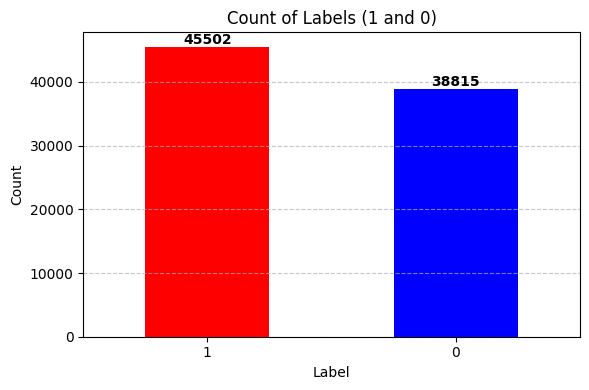

In [40]:
import matplotlib.pyplot as plt

final_phishing_df.columns = final_phishing_df.columns.str.strip()

label_counts = final_phishing_df['label'].value_counts()


plt.figure(figsize=(6, 4))
ax = label_counts.plot(kind='bar', color=['red', 'blue'])

plt.title('Count of Labels (1 and 0)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for p in ax.patches:
    ax.annotate(
        str(p.get_height()),                   
        (p.get_x() + p.get_width() / 2, p.get_height()), 
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.show()

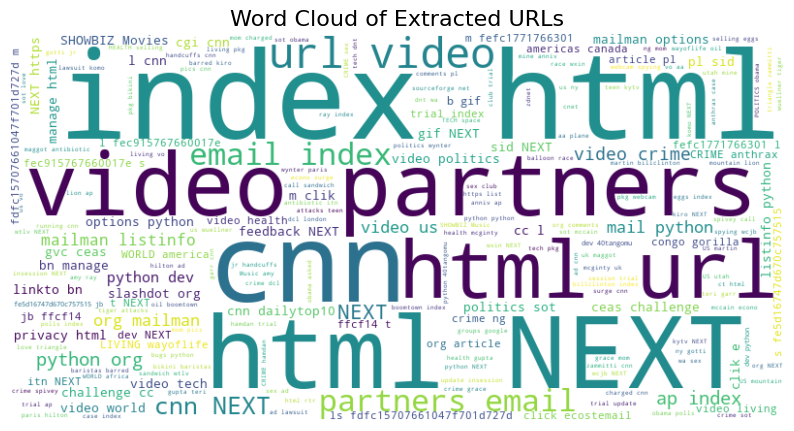

In [41]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Combine all URLs into one string (drop NaN and convert to str)
url_text = " ".join(final_phishing_df['URL'].dropna().astype(str))

# Generate the word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',
    max_words=200
).generate(url_text)

# Plot the word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Extracted URLs", fontsize=16)
plt.show()

In [42]:
# Replace newline characters with a space in the 'body' column
final_phishing_df['body'] = final_phishing_df['body'].astype(str).str.replace('\n', '  ', regex=False)

In [43]:
final_phishing_df.columns

Index(['subject', 'body', 'URL', 'label', 'URL_COUNT'], dtype='object')

In [44]:
import re
import pandas as pd

# Regex patterns
url_pattern = r'(https?://[^\s]+)'
phone_pattern = r'(\+?\d[\d\-\(\)\s]{6,}\d)'   # detects most global phone formats

def create_combined_text(row):
    subject = str(row['subject']) if pd.notnull(row['subject']) else ""
    body = str(row['body']) if pd.notnull(row['body']) else ""
    
    # Replace URLs with [LINK] if present
    if row['URL_COUNT'] > 0:
        body = re.sub(url_pattern, '[LINK]', body)
    else:
        # Even if URL_COUNT == 0, ensure no missed replacements
        body = re.sub(url_pattern, '[LINK]', body)
    
    # Replace phone numbers with [PHONE]
    body = re.sub(phone_pattern, '[PHONE]', body)
    
    # Combine with special tokens
    combined = f"[SSUB] {subject.strip()} [ESUB] [SBODY] {body.strip()} [EBODY]"
    return combined

# Apply to your DataFrame
final_phishing_df['text_combined'] = final_phishing_df.apply(create_combined_text, axis=1)


In [45]:
final_phishing_df = final_phishing_df.drop_duplicates()

In [46]:
final_phishing_df.to_csv("final_phishing_df.csv", index=False)

In [48]:
import pandas as pd

file_path = r"C:\Users\ATHARVA\Downloads\my codes\python\machine_learning\project_web\final_phishing_df.csv"

final_phishing_df= pd.read_csv(file_path)



In [49]:
import pandas as pd



# Determine the minimum class count
min_count = final_phishing_df['label'].value_counts().min()

# Sample equal number of rows from each class
balanced_df = final_phishing_df.groupby('label').sample(n=min_count, random_state=42)

# Optional: shuffle the final balanced dataset
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [51]:
balanced_df['label'].value_counts()

label
1    21503
0    21503
Name: count, dtype: int64

In [50]:
(balanced_df['URL_COUNT'] > 0).sum()

np.int64(29374)

In [53]:
balanced_df.to_csv("balanced_final_phishing_df.csv", index=False)

In [52]:
Bert_Data = balanced_df[['text_combined','label']]
Bert_Data.to_csv("Bert_Data.csv", index=False)

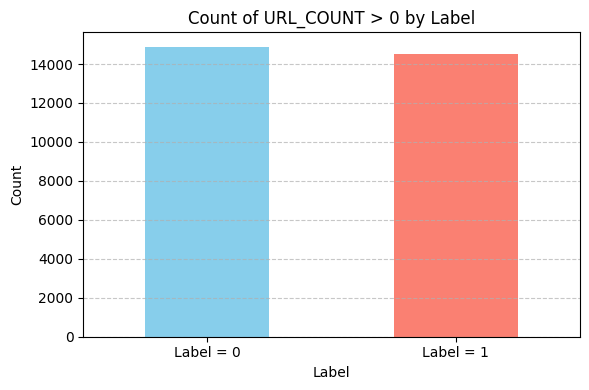

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter rows where URL_COUNT > 0
filtered_df = balanced_df[balanced_df['URL_COUNT'] > 0]

# Count how many rows have label 0 and label 1
label_counts = filtered_df['label'].value_counts().sort_index()

# Plotting
plt.figure(figsize=(6, 4))
label_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Count of URL_COUNT > 0 by Label')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Label = 0', 'Label = 1'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
Bert_Data['label'].value_counts()

In [ ]:
import pandas as pd

# Load original full dataset
final_phishing_df = pd.read_csv(r"C:\Users\ATHARVA\Downloads\my codes\python\machine_learning\project_web\final_phising_df.csv")

# Load saved Bert_data
Bert_data = pd.read_csv(r"C:\Users\ATHARVA\Downloads\my codes\python\machine_learning\project_web\Bert_data.csv")

# Reconstruct balanced_df by merging on 'text_combined'
balanced_df = final_phishing_df.merge(Bert_data, on='text_combined', how='inner')

# Optional: verify label consistency
assert all(balanced_df['label_x'] == balanced_df['label_y']), "Label mismatch detected!"

# Clean up duplicate label columns
balanced_df = balanced_df.drop(columns=['label_y']).rename(columns={'label_x': 'label'})

In [ ]:
import pandas as pd

file_path = r"C:\Users\ATHARVA\Downloads\my codes\python\machine_learning\project_web\Bert_data.csv"

Bert_data= pd.read_csv(file_path)


In [ ]:
Bert_data['label'].value_counts()

In [ ]:
Bert_data